In [1]:
import os
from collections import defaultdict

import numpy as np

import torch
import blobfile as bf
import transformer_lens
from huggingface_hub import hf_hub_download
from sae_lens import SparseAutoencoderDictionary
import sparse_autoencoder

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from operations import (
    low_rank_mvm,
    kronecker_mvm,
    sum_kronecker_mvm,
    # useful to have the mmms here to directly train on distance between matrices
    low_rank_mmm,
    kronecker_mmm,
    sum_kronecker_mmm,
)

In [2]:
!nvidia-smi

Thu Aug  1 21:23:47 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.14              Driver Version: 550.54.14      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          On  |   00000000:C4:00.0 Off |                    0 |
| N/A   37C    P0             53W /  300W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32
torch.set_default_dtype(dtype)

In [4]:
model = transformer_lens.HookedTransformer.from_pretrained("gpt2", center_writing_weights=False)
# device = next(model.parameters()).device

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Loaded pretrained model gpt2 into HookedTransformer


In [5]:
prompt = "This is an example of a prompt that"
tokens = model.to_tokens(prompt)  # (1, n_tokens)
with torch.no_grad():
    logits, activation_cache = model.run_with_cache(tokens, remove_batch_dim=True)

layer_index = 7
location = "resid_post_mlp"

transformer_lens_loc = {
    "mlp_post_act": f"blocks.{layer_index}.mlp.hook_post",
    "resid_delta_attn": f"blocks.{layer_index}.hook_attn_out",
    "resid_post_attn": f"blocks.{layer_index}.hook_resid_mid",
    "resid_delta_mlp": f"blocks.{layer_index}.hook_mlp_out",
    "resid_post_mlp": f"blocks.{layer_index}.hook_resid_post",
}[location]

with bf.BlobFile(sparse_autoencoder.paths.v5_32k(location, layer_index), mode="rb") as f:
    state_dict = torch.load(f)
    autoencoder = sparse_autoencoder.Autoencoder.from_state_dict(state_dict)
    autoencoder.to(device)

input_tensor = activation_cache[transformer_lens_loc]

input_tensor_ln = input_tensor

with torch.no_grad():
    latent_activations, info = autoencoder.encode(input_tensor_ln)
    reconstructed_activations = autoencoder.decode(latent_activations, info)

normalized_mse = (reconstructed_activations - input_tensor).pow(2).sum(dim=1) / (input_tensor).pow(2).sum(dim=1)
print(location, normalized_mse)

### Use Joseph Bloom instead of OpenAI

In [7]:
# load Joseph Bloom's GPT-2 SAEs as a backup
def get_gpt2_sae(device, layer):

    if type(device) == int:
        device = f"cuda:{device}"

    GPT2_SMALL_RESIDUAL_SAES_REPO_ID = "jbloom/GPT2-Small-SAEs-Reformatted"
    hook_point = f"blocks.{layer}.hook_resid_pre"

    FILENAME = f"{hook_point}/cfg.json"
    path = hf_hub_download(repo_id=GPT2_SMALL_RESIDUAL_SAES_REPO_ID, filename=FILENAME)

    FILENAME = f"{hook_point}/sae_weights.safetensors"
    hf_hub_download(repo_id=GPT2_SMALL_RESIDUAL_SAES_REPO_ID, filename=FILENAME)

    FILENAME = f"{hook_point}/sparsity.safetensors"
    hf_hub_download(repo_id=GPT2_SMALL_RESIDUAL_SAES_REPO_ID, filename=FILENAME)

    folder_path = os.path.dirname(path)

    return SparseAutoencoderDictionary.load_from_pretrained(
            folder_path, device=device
        )[f"blocks.{layer}.hook_resid_pre"]

sae = get_gpt2_sae('cpu', 7)

In [10]:
for name, _ in sae.named_parameters():
    print(name)

W_enc
b_enc
W_dec
b_dec
scaling_factor


In [17]:
W_dec = sae.W_dec.T

In [18]:
W_dec.shape

torch.Size([768, 24576])

In [ ]:
# W_dec = autoencoder.decoder.weight.data.clone()

In [19]:
W_dec.shape

torch.Size([768, 24576])

In [20]:
# compute prime factorization
def prime_factors(n):
    """Returns list of prime factors of n.
    >>> prime_factors(10)
    [2, 5]
    >>> prime_factors(32)
    [2, 2, 2, 2, 2]
    """
    i = 2
    factors = []
    while i * i <= n:
        if n % i:
            i += 1
        else:
            n //= i
            factors.append(i)
    if n > 1:
        factors.append(n)
    return factors

In [21]:
prime_factors(768)

[2, 2, 2, 2, 2, 2, 2, 2, 3]

In [22]:
# let's learn a low-rank approximation of W_dec
d, n = W_dec.shape
ranks = [32, 64, 128, 256, 512, 768, 1024]

steps = list(range(5_000))
losses = defaultdict(list)

for rank in tqdm(ranks):
    var_W_dec = torch.var(W_dec)
    scaling = (var_W_dec / 2).sqrt()
    W1 = torch.randn(d, rank, device=device, dtype=dtype) * (scaling / np.sqrt(rank))
    W1 = W1.requires_grad_(True)
    W2 = torch.randn(n, rank, device=device, dtype=dtype) * (scaling / np.sqrt(rank))
    W2 = W2.requires_grad_(True)

    optimizer = torch.optim.Adam([W1, W2], lr=1e-3)

    for step in steps:
        optimizer.zero_grad()
        W_dec_approx = low_rank_mmm(W1, W2)
        loss = (W_dec - W_dec_approx).pow(2).mean()
        loss.backward()
        optimizer.step()
        losses[rank].append(loss.item())

  0%|          | 0/7 [00:00<?, ?it/s]

ValueError: can't optimize a non-leaf Tensor

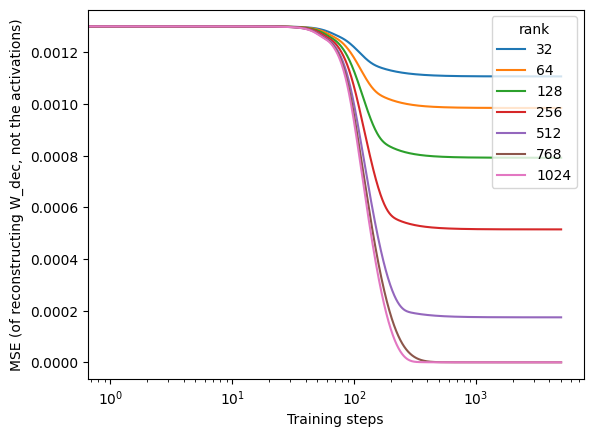

In [24]:
for rank in ranks:
    plt.plot(steps, losses[rank], label=rank)
plt.legend(title="rank", loc='upper right')
plt.xlabel("Training steps")
plt.ylabel("MSE (of reconstructing W_dec, not the activations)")
plt.xscale('log')

In [26]:
# compute the number of parameters in each low-rank approximation
for rank in ranks:
    print(f"Rank {rank}: {(d * rank + n * rank) / (d * n)}")

Rank 32: 0.042643229166666664
Rank 64: 0.08528645833333333
Rank 128: 0.17057291666666666
Rank 256: 0.3411458333333333
Rank 512: 0.6822916666666666
Rank 768: 1.0234375
Rank 1024: 1.3645833333333333


In [ ]:
# let's learn a kronecker product approximation of W_dec
d_factors = prime_factors(d)
n_factors = prime_factors(n)

